# 📦 BUILDING A SYNTHETIC BLOCK MODEL

This notebook generates a **synthetic 3D block model** for a mining operation. It is designed to replicate the structure, spatial distribution, and economic attributes typically found in real-world geological models — but with complete control over inputs and logic.

The purpose is to:
- Simulate realistic orebody geometries and domains
- Assign geological, geophysical and economic attributes to blocks
- Enable easy customisation for testing, visualisation or teaching
- Explore cut-off classification, domain masking, and spatial continuity

---

## 🧭 Notebook Overview

The workflow is modular, with each section handling a key step in the process:

### 🔧 1. **User Parameter Inputs**
- Define model geometry (extent, block size)
- Specify mineral properties (grade ranges, noise parameters)
- Input economic parameters (prices, units, recoveries, exchange rates)
- Configure geophysical properties (e.g. density)
- Define domain geometries (e.g. cylindrical, ellipsoid, tabular)

### 🏗️ 2. **Block Model Generation Engine**
- Creates a 3D geospatial grid of blocks (with X, Y, Z coordinates)
- Assigns base attributes based on user-defined noise functions

### ⚒️ 3. **Property Assignment**
- Assigns grades (Au, Cu) using Perlin noise for spatial continuity
- Calculates value per tonne based on grade, recovery, price, and density
- Classifies blocks as Ore or Waste based on user-defined cut-off
- Adds physical properties (e.g. density)

### 🧭 4. **Domain Masking**
- Applies spatial rules to define geological domains (e.g. orebody core)
- Tags each block with its corresponding domain (or background)

### 📊 5. **Interactive Visualisation & Analysis**
- Explore horizontal and vertical slices interactively
- Filter by property, domain, depth or cross-section
- Toggle overlays (e.g. domain contours)
- Export synthetic block models for further use

---

## 🚧 Future Enhancements (To Be Implemented)

- Vertical section viewer (X or Y directions)
- Export tools (CSV, 3D viewers)
- Integration of structural features (e.g. faults, dips)
- Probabilistic or multi-element classification
- Multiple orebodies or nested domains

---

This notebook is modular and extensible — useful for concept testing, educational demonstrations, or early-stage prototyping of Mine-to-Mill optimisation or resource modelling approaches.


### STEP 1: DEFINE USER PARAMETERS

This section contains all user-configurable inputs. These parameters define the geometry, geological properties, economics, and domains of the synthetic block model.

Each section below is modular, allowing easy adjustment or extension for more complex simulations.

---

#### 📐 Model Geometry
- Define the 3D spatial extent of the block model (in metres)
- Set block resolution (X, Y, Z block sizes)
- Origin is assumed to be (0, 0, 0)

#### 🪨 Mineral Properties
- Specify mineral grades (e.g. Au, Cu) using Perlin noise
- Define grade ranges, spatial smoothness, and reproducible random seeds

#### 🧲 Geophysical Data
- Density values assigned per block using noise-based distribution
- Useful for downstream economic calculations

#### 💰 Economic Parameters
- Set commodity prices (in USD), recoveries, and units (e.g. oz, %)
- Specify exchange rates to convert to AUD
- Handles both weight-based and grade-based unit conversions

#### 🧱 Domain Definitions
- Define geological domains (e.g. Orebody, Core) using shapes like:
	- Cylinders
	- Ellipsoids
	- Tabular bodies (optional)
- Each domain is defined by centre, shape, size, and depth extent
- Used for masking, classification, and spatial filtering

#### 🎨 Domain Colours
- Visual mapping of domains for overlay plotting
- Customisable colour scheme for easier interpretation

#### 🧪 Advanced Geometallurgical Properties (Optional)
This section includes optional properties used in geometallurgical and processing models:
- Comminution indices (A*b, BWi, DWi) to estimate throughput or energy use
- Geomechanical parameters (UCS, RMR) to simulate strength or blasting requirements
- Floatability or reagent indices to simulate processing behaviour

These are simulated using noise-based distributions similar to grade and density

---

All values defined here will feed into the block generation engine and visualisation tools.


In [225]:
### STEP 1: DEFINE USER PARAMETERS ###

# --- Model Geometry ---
model_dimensions = {
	"origin": (0, 0, 0),          # Origin of the model (x0, y0, z0)
	"extent": (500, 500, 100),    # Overall size of the model in metres (X, Y, Z)
	"block_size": (25, 25, 10),   # Size of each block in metres (X, Y, Z)
}

# --- Mineral Properties ---
# These define synthetic grade distributions using Perlin noise
# - noise_scale controls the spatial frequency (lower = smoother)
# - octaves adds layers of detail (higher = more complexity)
# - seed ensures reproducibility
minerals = {
	"Au": {
		"grade_range": (0.0, 3.5),   # Grade range in g/t
		"noise_scale": 0.05,         # Spatial smoothness
		"octaves": 2,                # Noise complexity
		"seed": 42                   # Random seed
	},
	"Cu": {
		"grade_range": (0.0, 1.2),   # Grade range in %
		"noise_scale": 0.04,
		"octaves": 3,
		"seed": 24
	}
}

primary_mineral = "Au_grade"  		# Main mineral for economic analysis
primary_mineral_unit = "g/t"		# Unit for primary mineral
secondary_mineral = "Cu_grade" 		# Secondary mineral for economic analysis
secondary_mineral_unit = "%"		# Unit for secondary mineral

# --- Geophysical Data ---
# Simulate density or other physical properties using noise
geophysical_data = {
	"density": {
		"range": (2.4, 3.0),         # g/cm³ (typical for hard rock)
		"noise_scale": 0.03,
		"octaves": 1,
		"seed": 99
	}
}

# --- Economic Data ---

# Currency setup for conversions
target_currency = "AUD"  # Target output currency

exchange_rates = {
	"AUD": 1.0,
	"USD": 1 / 1.5,
	"CAD": 0.91,
}

# Commodity pricing and recovery assumptions
economic_data = {
	"Au": {
		"price_per_oz_usd": 1950,   # USD/oz
		"recovery": 0.92,           # Metallurgical recovery (fraction)
		"unit": "oz"                # Grade is in g/t
	},
	"Cu": {
		"price_per_lb_usd": 4.0,    # USD/lb
		"recovery": 0.88,
		"unit": "%"                 # Grade is in %
	}
}

# --- Domain Data ---

# Derived extent (used for domain positioning)
extent = (
	model_dimensions["extent"][0],  # X max
	model_dimensions["extent"][1],  # Y max
	model_dimensions["extent"][2],  # Z max
)

# Display ranges for interactive plotting
property_display_ranges = {
	"Au_grade": (0, 3.5),  			# g/t (gold grade)
	"Cu_grade": (0, 1.2),			# % (copper grade)
	"density": (2.4, 3.0),  		# g/cm³ (density)
	"value_per_tonne": (0, 300)		# currency/t (economic value)
}

# Preferred colourmaps per property for consistent visualisation
property_colormaps = {
	"Au_grade": "plasma",                	# High contrast, good for gold
	"Cu_grade": "viridis",              	# Colourblind-friendly
	"density": "cividis",               	# Monotonic, geophysical
	"value_per_tonne": "inferno",       	# Darker theme for economics
	"value_Au_per_tonne": "plasma",
	"value_Cu_per_tonne": "viridis",
	"class": "Set1",                    	# Categorical for Ore/Waste
}

# Human-readable labels for plots and legends
property_labels = {
	"Au_grade": "Au Grade (g/t)",
	"Cu_grade": "Cu Grade (%)",
	"density": "Density (g/cm³)",
	"value_per_tonne": "Value (AUD/t)",
	"value_Au_per_tonne": "Au Value (AUD/t)",
	"value_Cu_per_tonne": "Cu Value (AUD/t)",
	"class": "Classification",
}


# Domain geometry definitions
# Each domain can be:
# - "cylinder" (for vertical orebodies)
# - "ellipsoid" (for subdomains/cores)
# - "tabular" (for flat seams or veins)
# Center defines the X-Y midpoint
# depth_range defines the vertical extent (Z)
domain_definitions = {
	"Orebody": {
		"shape": "cylinder",
		"center": (extent[0] / 2, extent[1] / 2),  # Midpoint of model
		"radius": 100,                             # Radius in XY plane
		"depth_range": (20, 80)                    # Vertical extent
	},
	"Core": {
		"shape": "ellipsoid",
		"center": (extent[0] / 2, extent[1] / 2),
		"semi_axes": (50, 50, 20),                 # Semi-axes in X, Y, Z
		"depth_range": (30, 70)
	}
}

# Colours used for outlining domain boundaries in visualisations
domain_colours = {
	"Orebody": "red",
	"Core": "blue",
	"Background": "grey"  # Optional — not usually outlined
}

# --- Drillhole Simulation Parameters ---
# Defines how many holes are simulated and how they're selected
drillhole_parameters = {
	"n_holes": 10,       # Number of drillholes to sample from the block model
	"random_seed": 10    # Seed for reproducible hole selection
}

# --- Advanced Geometallurgical Properties (Optional) ---
# These properties mimic geometallurgical and geomechanical characteristics
# Use Perlin noise to generate realistic spatial patterns

# Enable optional enhancements
enable_advanced_properties = True
enable_geophysical_properties = True
enable_geomechanical_properties = True
enable_metallurgical_properties = True
enable_processing_indices = True
enable_categorical_attributes = True

if enable_advanced_properties:
	advanced_properties = {
		"UCS": {  # Uniaxial Compressive Strength (MPa)
			"range": (50, 150),
			"noise_scale": 0.04,
			"octaves": 2,
			"seed": 71
		},
		"Axb": {  # Drop Weight Index (comminution hardness)
			"range": (30, 120),
			"noise_scale": 0.06,
			"octaves": 2,
			"seed": 72
		},
		"BWi": {  # Bond Ball Work Index (kWh/t)
			"range": (8, 20),
			"noise_scale": 0.03,
			"octaves": 1,
			"seed": 73
		},
		"floatability_index": {  # Mineral floatability index
			"range": (0.1, 0.9),
			"noise_scale": 0.05,
			"octaves": 3,
			"seed": 74
		},
		"reagent_demand_index": {  # Reagent demand index
			"range": (20, 80),
			"noise_scale": 0.04,
			"octaves": 2,
			"seed": 75
		}
	}

if enable_geophysical_properties:
	geophysical_data.update({
		"mag_sus": {  # Magnetic Susceptibility
			"range": (0.001, 0.1),       # SI units
			"noise_scale": 0.03,
			"octaves": 1,
			"seed": 13
		},
		"resistivity": {
			"range": (100, 1000),        # ohm.m
			"noise_scale": 0.02,
			"octaves": 2,
			"seed": 14
		},
		"gamma": {
			"range": (0, 200),           # API units
			"noise_scale": 0.02,
			"octaves": 2,
			"seed": 15
		}
	})

if enable_geomechanical_properties:
	geomechanical_data = {
		"UCS": {  # Uniaxial Compressive Strength
			"range": (20, 200),          # MPa
			"noise_scale": 0.03,
			"octaves": 1,
			"seed": 16
		},
		"RMR": {  # Rock Mass Rating (or GSI)
			"range": (30, 80),
			"noise_scale": 0.03,
			"octaves": 1,
			"seed": 17
		}
	}

if enable_metallurgical_properties:
	met_data = {
		"Axb": {
			"range": (30, 120),
			"noise_scale": 0.04,
			"octaves": 1,
			"seed": 18
		},
		"BWi": {
			"range": (8, 20),  # Bond Ball Mill Work Index
			"noise_scale": 0.04,
			"octaves": 1,
			"seed": 19
		},
		"DWi": {
			"range": (3, 10),  # Drop Weight Index
			"noise_scale": 0.04,
			"octaves": 1,
			"seed": 20
		},
		"grindability": {
			"range": (0, 1),  # Index value
			"noise_scale": 0.04,
			"octaves": 1,
			"seed": 21
		}
	}

if enable_processing_indices:
	processing_indices = {
		"floatability_index": {
			"range": (0.0, 1.0),
			"noise_scale": 0.03,
			"octaves": 1,
			"seed": 22
		},
		"reagent_demand": {
			"range": (0, 100),  # arbitrary units for leach cost
			"noise_scale": 0.03,
			"octaves": 1,
			"seed": 23
		}
	}

if enable_categorical_attributes:
	processing_categories = {
		"oxidation_zone": ["Fresh", "Transition", "Oxide"],
		"processing_route": ["Float", "Leach", "Bioleach"]
	}

	geological_categories = {
		"lith_code": ["DIO", "SH", "GRAN", "OX"],
		"stratigraphy": ["Fm_A", "Member_B"],
		"alteration": ["Sericite", "Chlorite"],
		"grain_size": ["Fine", "Medium", "Coarse"]
	}

property_display_ranges.update({
	"UCS": (50, 150),					# MPa (rock strength)
	"Axb": (30, 120),					# Drop-weight index (dimensionless)
	"BWi": (8, 20),						# kWh/t (Bond Work Index - energy required for grinding)
	"floatability_index": (0.1, 0.9),	# Index (0–1 scale, float response)
	"reagent_demand_index": (20, 80)	# Units could be g/t or relative index
})

# Update colourmaps for advanced properties
property_colormaps.update({
	"UCS": "coolwarm",                  # Diverging scale for strength
	"Axb": "magma",                     # Deep range for breakage indices
	"BWi": "magma",                     # Consistent with Axb
	"floatability_index": "YlGnBu",     # Lighter, for index scale
	"reagent_demand_index": "OrRd"      # Warmer tones
})

# Update labels for advanced properties
property_labels.update({
	"UCS": "Unconfined Comp. Strength (MPa)",
	"Axb": "A×b Index",
	"BWi": "Bond Work Index (kWh/t)",
	"floatability_index": "Floatability Index",
	"reagent_demand_index": "Reagent Demand Index"
})


### STEP 2: BLOCK MODEL GENERATION ENGINE

This step builds the synthetic 3D block model using user-defined parameters from Step 1. It generates a block for every position in the X-Y-Z grid and assigns spatially correlated values using Perlin noise.

---

#### 🔢 What this step does:

1. **Compute grid resolution** from the model dimensions and block size
2. **Loop through every block** position (x, y, z)
3. **Calculate block centre coordinates**
4. **Assign mineral grades** using Perlin noise (smooth, realistic patterns)
5. **Assign geophysical properties** (e.g. density)
6. Store results in a clean `pandas.DataFrame` for later filtering, classification and visualisation

---

#### 🧠 Notes on Implementation:

- **Perlin noise** produces smooth spatial variation rather than random noise, simulating realistic mineralisation patterns
- Noise parameters (scale, octaves, seed) control the smoothness and structure of the synthetic data
- All block properties are fully customisable via the Step 1 parameter dictionary
- Block centre coordinates are calculated from origin and block dimensions (not corners)
- The final `block_model_df` contains one row per block, with all assigned values


In [226]:
import numpy as np
import pandas as pd
from noise import pnoise3
from tqdm.notebook import tqdm

tqdm.pandas()

# --- 1. Extract geometry info ---
origin = model_dimensions["origin"]
extent = model_dimensions["extent"]
block_size = model_dimensions["block_size"]

nx = int(extent[0] / block_size[0])
ny = int(extent[1] / block_size[1])
nz = int(extent[2] / block_size[2])

# --- 2. Create empty block model list ---
block_list = []

# --- 3. Loop through 3D grid and populate properties ---
for k in tqdm(range(nz), desc="Z Levels"):
	for j in range(ny):
		for i in range(nx):
			x = origin[0] + (i + 0.5) * block_size[0]
			y = origin[1] + (j + 0.5) * block_size[1]
			z = origin[2] + (k + 0.5) * block_size[2]

			block_data = {"x": x, "y": y, "z": z}

			# Assign mineral grades
			for mineral, params in minerals.items():
				noise_val = pnoise3(i * params["noise_scale"],
									j * params["noise_scale"],
									k * params["noise_scale"],
									octaves=params["octaves"],
									repeatx=1024, repeaty=1024, repeatz=1024,
									base=params["seed"])
				noise_val = (noise_val + 1) / 2
				min_val, max_val = params["grade_range"]
				grade = min_val + noise_val * (max_val - min_val)
				block_data[f"{mineral}_grade"] = grade

			# Geophysical properties
			if enable_geophysical_properties:
				for prop, params in geophysical_data.items():
					noise_val = pnoise3(i * params["noise_scale"],
										j * params["noise_scale"],
										k * params["noise_scale"],
										octaves=params["octaves"],
										repeatx=1024, repeaty=1024, repeatz=1024,
										base=params["seed"])
					noise_val = (noise_val + 1) / 2
					min_val, max_val = params["range"]
					block_data[prop] = min_val + noise_val * (max_val - min_val)

			# Geomechanical properties
			if enable_geomechanical_properties:
				for prop, params in geomechanical_data.items():
					noise_val = pnoise3(i * params["noise_scale"],
										j * params["noise_scale"],
										k * params["noise_scale"],
										octaves=params["octaves"],
										repeatx=1024, repeaty=1024, repeatz=1024,
										base=params["seed"])
					noise_val = (noise_val + 1) / 2
					min_val, max_val = params["range"]
					block_data[prop] = min_val + noise_val * (max_val - min_val)

			# Metallurgical properties
			if enable_metallurgical_properties:
				for prop, params in met_data.items():
					noise_val = pnoise3(i * params["noise_scale"],
										j * params["noise_scale"],
										k * params["noise_scale"],
										octaves=params["octaves"],
										repeatx=1024, repeaty=1024, repeatz=1024,
										base=params["seed"])
					noise_val = (noise_val + 1) / 2
					min_val, max_val = params["range"]
					block_data[prop] = min_val + noise_val * (max_val - min_val)

			# Processing indices
			if enable_processing_indices:
				for prop, params in processing_indices.items():
					noise_val = pnoise3(i * params["noise_scale"],
										j * params["noise_scale"],
										k * params["noise_scale"],
										octaves=params["octaves"],
										repeatx=1024, repeaty=1024, repeatz=1024,
										base=params["seed"])
					noise_val = (noise_val + 1) / 2
					min_val, max_val = params["range"]
					block_data[prop] = min_val + noise_val * (max_val - min_val)

			# Categorical geological properties
			if enable_categorical_attributes:
				for prop, categories in geological_categories.items():
					block_data[prop] = np.random.choice(categories)

				# Categorical processing attributes
				for prop, categories in processing_categories.items():
					block_data[prop] = np.random.choice(categories)

			block_list.append(block_data)

# --- 4. Convert to DataFrame ---
block_model_df = pd.DataFrame(block_list)

Z Levels:   0%|          | 0/10 [00:00<?, ?it/s]

### STEP 3: BLOCK MODEL VISUALISATION

This section provides multiple ways to explore the synthetic block model using both static and interactive tools. Each method enables inspection of spatial variation across depth, orientation, and property type.

---

#### 🖼️ 3.1: Static Visualisation

- **Horizontal Slices** (Z-level): Shows planar views of properties at specific depths
- **Vertical Sections** (X or Y direction): Reveals cross-sectional views through the model
- **3D Scatter Plot**: An interactive view for spatial context using Plotly

---

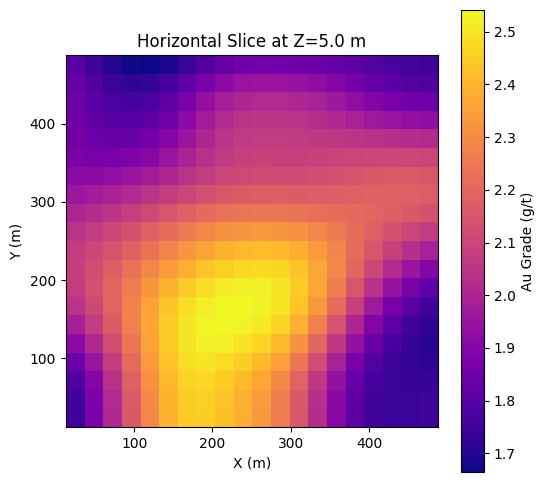

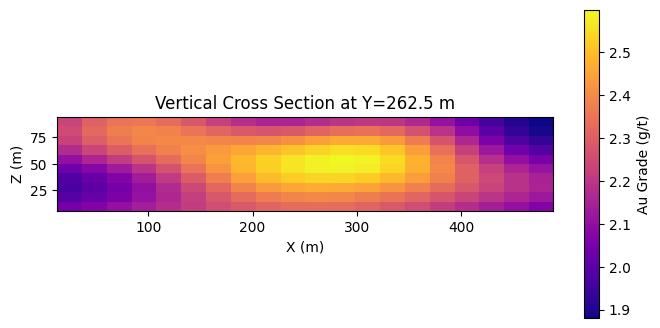

In [227]:
### 1. Horizontal Slice (Z-level) ###

import matplotlib.pyplot as plt

# Choose Z level to slice (near surface = low Z)
z_slice_value = block_model_df['z'].unique()[0]  # or choose manually

# Filter to slice
slice_df = block_model_df[block_model_df['z'] == z_slice_value]

# Pivot for plotting
pivot = slice_df.pivot(index='y', columns='x', values=primary_mineral)

cmap = property_colormaps.get(primary_mineral, 'plasma')

# Plot
plt.figure(figsize=(6, 6))
plt.imshow(pivot.values, origin='lower', cmap=cmap, extent=[pivot.columns.min(), pivot.columns.max(), pivot.index.min(), pivot.index.max()])
plt.title(f"Horizontal Slice at Z={z_slice_value} m")
plt.colorbar(label=property_labels.get(primary_mineral, primary_mineral))
plt.xlabel('X (m)')
plt.ylabel('Y (m)')
plt.show()

### 2. Vertical Cross Section (Y or X) ###

# Choose Y value for cross-section
y_section_value = block_model_df['y'].unique()[int(len(block_model_df['y'].unique())/2)]

# Filter to cross-section
section_df = block_model_df[block_model_df['y'] == y_section_value]

# Pivot for plotting
pivot = section_df.pivot(index='z', columns='x', values=primary_mineral)

# Plot
plt.figure(figsize=(8, 4))
plt.imshow(pivot.values, origin='lower', cmap=cmap, extent=[pivot.columns.min(), pivot.columns.max(), pivot.index.min(), pivot.index.max()])
plt.title(f"Vertical Cross Section at Y={y_section_value} m")
plt.colorbar(label=property_labels.get(primary_mineral, primary_mineral))
plt.xlabel('X (m)')
plt.ylabel('Z (m)')
plt.show()

### 3. 3D Scatter Plot (Plotly) ###

import plotly.express as px

# Sample (optional) if dataset is large
sample_df = block_model_df.sample(frac=0.2, random_state=1)

fig = px.scatter_3d(sample_df,
					x='x', y='y', z='z',
					color=primary_mineral,
					color_continuous_scale=cmap,
					labels={primary_mineral: property_labels.get(primary_mineral, primary_mineral)},
					opacity=0.6,
					size_max=2,
					title=f'3D Block Model - {property_labels.get(primary_mineral, primary_mineral)}')
fig.update_layout(scene=dict(
	xaxis_title='X (m)',
	yaxis_title='Y (m)',
	zaxis_title='Z (m)'),
	margin=dict(l=0, r=0, b=0, t=30))
fig.show()



#### 🎞️ 3.2: Animated Slices

- Scroll through Z-level slices to simulate moving down through the model.
- Useful for seeing how mineralisation changes with depth.

---

In [228]:
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import HTML

# Z levels
z_levels = sorted(block_model_df['z'].unique())

# Set colour scale limits based on known grade range
vmin, vmax = 0, 3.5  # Or use block_model_df['Au_grade'].min(), max()

# Set up figure
fig, ax = plt.subplots(figsize=(6, 6))
img = ax.imshow(np.zeros((ny, nx)), cmap=cmap, origin='lower',
				extent=[0, extent[0], 0, extent[1]],
				vmin=vmin, vmax=vmax)
cbar = plt.colorbar(img, ax=ax)
cbar.set_label(property_labels.get(primary_mineral, primary_mineral))

def update(frame):
	z_val = z_levels[frame]
	slice_df = block_model_df[block_model_df['z'] == z_val]
	pivot = slice_df.pivot(index='y', columns='x', values=primary_mineral)
	pivot = pivot.sort_index(ascending=True).sort_index(axis=1, ascending=True).fillna(0)

	img.set_data(pivot.values)
	ax.set_title(f"Z-slice at Depth = {z_val} m")
	return [img]

ani = animation.FuncAnimation(fig, update, frames=len(z_levels), interval=500)
plt.close()

HTML(ani.to_jshtml())



#### 🧭 3.3: Interactive Property Viewer

- Use dropdowns to explore different properties (e.g. `Au_grade`, `Cu_grade`, `density`) at different Z levels.
- Built with `ipywidgets` for dynamic slice navigation.

---

In [229]:
import ipywidgets as widgets
from IPython.display import display

# Dropdown to select property
property_dropdown = widgets.Dropdown(
	options=[col for col in block_model_df.columns if col not in ['x', 'y', 'z']],
	value=primary_mineral,
	description='Property:'
)

# Dropdown to select Z level
z_dropdown = widgets.Dropdown(
	options=sorted(block_model_df['z'].unique()),
	value=block_model_df['z'].unique()[0],
	description='Z Slice:'
)

# Interactive plot function
def plot_interactive_slice(property_name, z_val):
	if property_name not in block_model_df.columns:
		print(f"⚠️ Property '{property_name}' not found in block model.")
		return

	slice_df = block_model_df[block_model_df['z'] == z_val]
	pivot = slice_df.pivot(index='y', columns='x', values=property_name)
	cmap = property_colormaps.get(property_name, 'plasma')
	
	plt.figure(figsize=(6, 6))
	plt.imshow(pivot.values, cmap=cmap, origin='lower',
			   extent=[pivot.columns.min(), pivot.columns.max(), pivot.index.min(), pivot.index.max()])
	plt.title(f"{property_labels.get(property_name, property_name)} at Z={z_val} m")
	cbar_label = property_labels.get(property_name, property_name)
	plt.colorbar(label=cbar_label)
	plt.xlabel('X (m)')
	plt.ylabel('Y (m)')
	plt.show()

# Link widgets to plot
widgets.interact(plot_interactive_slice, property_name=property_dropdown, z_val=z_dropdown);


interactive(children=(Dropdown(description='Property:', options=('Au_grade', 'Cu_grade', 'density', 'mag_sus',…

#### 🪪 3.4: Vertical Section Viewer

- Interactively select a vertical cross-section by direction (`X` or `Y`) and position.
- Choose which property to visualise.
- Easily identify vertical patterns such as zonation or layering.

---

In [230]:
import ipywidgets as widgets
from IPython.display import display

# Dropdowns for property and orientation
property_dropdown = widgets.Dropdown(
	options=[col for col in block_model_df.columns if col not in ['x', 'y', 'z']],
	value=primary_mineral,
	description='Property:'
)

orientation_dropdown = widgets.Dropdown(
	options=['Y', 'X'],
	value='Y',
	description='Section Dir:'
)

# Slider placeholder (we’ll update based on orientation)
position_slider = widgets.FloatSlider(
	min=block_model_df['y'].min(),
	max=block_model_df['y'].max(),
	step=model_dimensions['block_size'][1],
	value=block_model_df['y'].mean(),
	description='Y Pos:'
)

# --- Initialise slider range based on orientation ---
def update_slider_range(orientation):
	if orientation == 'Y':
		return widgets.FloatSlider(
			min=block_model_df['y'].min(),
			max=block_model_df['y'].max(),
			step=model_dimensions['block_size'][1],
			value=block_model_df['y'].mean(),
			description="Y Pos:"
		)
	else:
		return widgets.FloatSlider(
			min=block_model_df['x'].min(),
			max=block_model_df['x'].max(),
			step=model_dimensions['block_size'][0],
			value=block_model_df['x'].mean(),
			description="X Pos:"
		)

import warnings
with warnings.catch_warnings():
	warnings.simplefilter("ignore")
	update_slider_range(orientation_dropdown.value)  # Just run it once


# --- Full viewer function ---
def vertical_section_viewer(property_name, orientation):
	pos_slider = update_slider_range(orientation)
	cmap = property_colormaps.get(property_name, 'plasma')


	def plot_section(pos_val):
		if orientation == 'Y':
			section_df = block_model_df[np.isclose(block_model_df['y'], pos_val)]
			pivot = section_df.pivot(index='z', columns='x', values=property_name)
			xlabel = 'X (m)'
		else:
			section_df = block_model_df[np.isclose(block_model_df['x'], pos_val)]
			pivot = section_df.pivot(index='z', columns='y', values=property_name)
			xlabel = 'Y (m)'

		pivot = pivot.sort_index().sort_index(axis=1).fillna(0)

		if pivot.empty:
			print(f"No data available at {orientation} = {pos_val}")
			return

		plt.figure(figsize=(8, 4))
		plt.imshow(pivot.values, cmap=cmap, origin='lower',
				   extent=[pivot.columns.min(), pivot.columns.max(), pivot.index.min(), pivot.index.max()])
		plt.colorbar(label=property_labels.get(property_name, property_name))
		plt.title(f"{property_labels.get(property_name, property_name)} Vertical Section at {orientation} = {pos_val:.2f} m")
		plt.xlabel(xlabel)
		plt.ylabel("Z (m)")
		plt.show()

	return widgets.interact(plot_section, pos_val=pos_slider)

# --- Main UI ---
vertical_section_viewer(property_name=property_dropdown.value, orientation=orientation_dropdown.value)


interactive(children=(FloatSlider(value=250.0, description='Y Pos:', max=487.5, min=12.5, step=25.0), Output()…

<function __main__.vertical_section_viewer.<locals>.plot_section(pos_val)>

#### 🔮 3.5 (Upcoming Enhancements)

- **Domain-aware visualisation**: View individual geological or economic domains
- **Zoom to domain** toggle
- **Overlay domain outlines** on slices for spatial context
---

### STEP 4: EXPORT BLOCK MODEL TO CSV

At this stage, we have a complete block model populated with:
- Spatial coordinates (`x`, `y`, `z`)
- Mineral grades (`Au`, `Cu`)
- Geophysical and economic data
- Domain classifications (e.g., Orebody, Core, Background)
- Value-based classification (`Ore` vs `Waste`)

You can now export the entire block model to a `.csv` file for use in:
- External tools (e.g., Excel, Deswik, Vulcan, Power BI)
- Further geostatistical or economic modelling
- Archival and version tracking

This step is optional but useful for downstream workflows.

We export the synthetic block model in 3 formats:

- **CSV** – For use in spreadsheets, GIS, or other software
- **Parquet** – Efficient storage format for reimporting into Pandas
- **JSON (line-delimited)** – Web/API-friendly for lightweight usage

Files will be saved under: `../data/`


In [231]:
import os

# Export path setup
export_path = "../data/"
filename_base = "synthetic_block_model"
os.makedirs(export_path, exist_ok=True)

# File paths
csv_path = os.path.join(export_path, f"{filename_base}.csv")
parquet_path = os.path.join(export_path, f"{filename_base}.parquet")
json_path = os.path.join(export_path, f"{filename_base}.json")

# --- Export formats ---
block_model_df.to_csv(csv_path, index=False)
block_model_df.to_parquet(parquet_path, index=False)
block_model_df.to_json(json_path, orient="records", lines=True)

# Confirmation
print("✅ Block model exported successfully:")
print(f"  • CSV:     {csv_path}")
print(f"  • Parquet: {parquet_path}")
print(f"  • JSON:    {json_path}")


✅ Block model exported successfully:
  • CSV:     ../data/synthetic_block_model.csv
  • Parquet: ../data/synthetic_block_model.parquet
  • JSON:    ../data/synthetic_block_model.json


### 🧾 STEP 5: ADD ECONOMICS TO THE BLOCK MODEL

We calculate the **value per tonne** for each block using:

$$
\text{\color{Aquamarine}Value per tonne} = \sum_i \left( \text{Grade}_i \times \text{Recovery}_i \times \text{Price}_i \right)
$$

- Supports multiple minerals with different price units (e.g., gold in USD/oz, copper in USD/lb)
- Automatically applies exchange rates to convert to target currency (e.g., AUD)
- Adds individual value columns for each mineral (`value_Au_per_tonne`, `value_Cu_per_tonne`)
- Computes total value per block as `value_per_tonne`
---

#### 💻 5.1: COMPUTE VALUE PER TONNE

Calculate value per block using recovery, price and units (oz/%), adjusted by exchange rate. One column per mineral is created, plus a combined total value column.


In [232]:
# --- Conversion constants ---
OZ_TO_GRAMS = 31.1035
LB_TO_KG = 0.453592

# Ensure clean slate
block_model_df['currency'] = target_currency

# --- Calculate value for each mineral ---
for mineral, econ in economic_data.items():
	grade_col = f"{mineral}_grade"
	value_col = f"value_{mineral}_per_tonne"

	if grade_col not in block_model_df.columns:
		continue

	recovery = econ["recovery"]
	unit = econ["unit"]
	exchange = exchange_rates[target_currency]

	if unit == "oz":
		# USD/oz → AUD/g
		price_per_g = (econ["price_per_oz_usd"] / OZ_TO_GRAMS) * exchange
		block_model_df[value_col] = block_model_df[grade_col] * recovery * price_per_g

	elif unit == "%":
		# USD/lb → AUD/kg, then multiply by % (as kg/t)
		price_per_kg = (econ["price_per_lb_usd"] / LB_TO_KG) * exchange
		block_model_df[value_col] = block_model_df[grade_col] * recovery * price_per_kg * 10  # % → kg/t

	else:
		raise ValueError(f"Unknown unit type for {mineral}: {unit}")

# --- Total value per block ---
value_cols = [col for col in block_model_df.columns if col.startswith("value_") and col.endswith("_per_tonne")]
block_model_df["value_per_tonne"] = block_model_df[value_cols].sum(axis=1)


### 🧭 5.2: VISUALISE BLOCK VALUE PER TONNE

Select a property to visualise from any value column or mineral grade using the dropdown viewer. Supports:

- `value_per_tonne` (total value)
- `value_Au_per_tonne`, `value_Cu_per_tonne`
- `Au_grade`, `Cu_grade`, `density`


In [233]:
exclude_cols = ['x', 'y', 'z', 'currency']
value_cols = [col for col in block_model_df.columns if col not in exclude_cols]

property_dropdown.options = value_cols  # Reuse existing dropdowns

widgets.interact(plot_interactive_slice,
				 property_name=property_dropdown,
				 z_val=z_dropdown)


interactive(children=(Dropdown(description='Property:', options=('Au_grade', 'Cu_grade', 'density', 'mag_sus',…

<function __main__.plot_interactive_slice(property_name, z_val)>

### 🪨 5.3: CLASSIFY BLOCKS – ORE VS WASTE

Apply a simple cut-off ($/tonne) to classify blocks as either **Ore** or **Waste** based on value:

- Adds a new column `class`
- Useful for visualisation or strategic mine planning


In [234]:
# Ore/waste cut-off
value_cutoff = 150  # AUD per tonne

block_model_df['class'] = np.where(
	block_model_df['value_per_tonne'] >= value_cutoff,
	'Ore', 'Waste'
)

# Summary stats
print("Value per tonne range:")
print(block_model_df['value_per_tonne'].describe())

print("\nOre vs Waste count:")
print(block_model_df['class'].value_counts())


Value per tonne range:
count    4000.000000
mean      171.781111
std        14.529779
min       129.138602
25%       160.953893
50%       172.779987
75%       183.500957
max       200.561003
Name: value_per_tonne, dtype: float64

Ore vs Waste count:
class
Ore      3700
Waste     300
Name: count, dtype: int64


### 🎨 5.4: VISUALISE ORE VS WASTE CLASS

Use the viewer to visualise the `class` column as a **categorical plot**:

- Colour-coded using Set1 colormap
- Legend labels shown as `Ore` and `Waste`
- Toggle between class and numeric properties


In [235]:
import ipywidgets as widgets
from IPython.display import display, clear_output

# Output area for plot
plot_output = widgets.Output()
display(plot_output)


def plot_interactive_slice(property_name, z_val):
	with plot_output:
		clear_output(wait=True)
		
		if property_name not in block_model_df.columns:
			print(f"⚠️ Property '{property_name}' not found in block model.")
			return

		slice_df = block_model_df[block_model_df['z'] == z_val]
		pivot = slice_df.pivot(index='y', columns='x', values=property_name)
		cmap = property_colormaps.get(property_name, 'plasma')

		if property_name == 'class':
			label_map = {'Waste': 0, 'Ore': 1}
			mapped_df = pivot.copy()
			for col in mapped_df.columns:
				mapped_df[col] = mapped_df[col].map(label_map).fillna(-1).astype(int)
			data = mapped_df.values
			vmin, vmax = 0, 1
		else:
			data = pivot.values
			vmin, vmax = property_display_ranges.get(property_name, (None, None))

		plt.figure(figsize=(6, 6))
		img = plt.imshow(data, cmap=cmap, origin='lower',
						 extent=[pivot.columns.min(), pivot.columns.max(),
								 pivot.index.min(), pivot.index.max()],
						 vmin=vmin, vmax=vmax)

		if property_name == 'class':
			cbar = plt.colorbar(img)
			cbar.set_ticks([0, 1])
			cbar.set_ticklabels(['Waste', 'Ore'])
		else:
			plt.colorbar(img, label=property_labels.get(property_name, property_name))

		plt.title(f"{property_labels.get(property_name, property_name)} at Z={z_val} m")
		plt.xlabel("X (m)")
		plt.ylabel("Y (m)")
		plt.xlim(0, model_dimensions["extent"][0])
		plt.ylim(0, model_dimensions["extent"][1])
		plt.show()

widgets.interact(
	plot_interactive_slice,
	property_name=property_dropdown,
	z_val=z_dropdown
)



Output()

interactive(children=(Dropdown(description='Property:', options=('Au_grade', 'Cu_grade', 'density', 'mag_sus',…

<function __main__.plot_interactive_slice(property_name, z_val)>

### Step 6: Geological Domains

Now that each block has a value and classification, we’ll spatially contextualise the model by adding **geological domains** such as the main orebody and its high-grade core.

These masks can be used for:
- Visual interpretation (outline overlays)
- Selective filtering (e.g., value within core only)
- Later steps like scheduling or reporting
---

#### 🧱 Step 6.1: Define Geological Domains (Orebody, Core, etc.)
We'll define user-customisable geological domains to simulate spatial structures such as:
* An **Orebody** defined as a cylindrical shape
* A **High-Grade Core** using an ellipsoidal zone
* A default **Background** domain for everything else

Each block will be assigned to one of these domains using its (x, y, z) coordinates and the domain definitions.

Domain masks allow:
* Spatial filtering for plotting
* Calculations within specific regions
* Overlaying domain outlines on 2D views

---

In [236]:
# Shape-based checker
def is_in_domain(row, params):
	shape = params["shape"]
	cx, cy = params["center"]
	z_min, z_max = params["depth_range"]

	dx = row["x"] - cx
	dy = row["y"] - cy
	dz = row["z"]

	if not (z_min <= dz <= z_max):
		return False

	if shape == "cylinder":
		r = params["radius"]
		return np.sqrt(dx**2 + dy**2) <= r

	elif shape == "ellipsoid":
		a, b, c = params["semi_axes"]
		dz_norm = (dz - z_min) / (z_max - z_min)
		return (dx/a)**2 + (dy/b)**2 + (dz_norm)**2 <= 1  # normalised vertical ellipsoid

	elif shape == "tabular":
		width_x = params.get("width_x", 100)
		return abs(dx) <= width_x / 2

	return False

# Assign domain names
def assign_domains(df, domain_defs):
	domain_flags = []

	for _, row in df.iterrows():
		label = "Background"  # Default
		for name, params in domain_defs.items():
			if is_in_domain(row, params):
				label = name
		domain_flags.append(label)

	df["domain"] = domain_flags
	return df

# Apply to block model
block_model_df = assign_domains(block_model_df, domain_definitions)

# Print the range of domain values
print("\nDomain counts:")
print(block_model_df['domain'].value_counts())



Domain counts:
domain
Background    3688
Orebody        280
Core            32
Name: count, dtype: int64


### 📊 6.2: SUMMARY STATISTICS BY DOMAIN

Generate summary statistics for each defined domain, including:

- Mean and standard deviation of economic value (`value_per_tonne`)
- Grade averages for `Au` and `Cu`
- Ore/Waste classification counts per domain
- Domain volume or block counts

This helps compare the economic potential of each domain and validate model realism.

---

In [237]:
import pandas as pd

# --- Group by domain ---
domain_summary = block_model_df.groupby('domain').agg({
	'value_per_tonne': ['mean', 'std', 'min', 'max'],
	'Au_grade': ['mean', 'std'],
	'Cu_grade': ['mean', 'std'],
	'class': lambda x: (x == 'Ore').sum(),  # Count of Ore blocks
})

# Rename for clarity
domain_summary.columns = ['_'.join(col).strip() for col in domain_summary.columns.values]
domain_summary.rename(columns={'class_<lambda>': 'ore_block_count'}, inplace=True)

# Add block count per domain
domain_summary['total_blocks'] = block_model_df.groupby('domain').size()
domain_summary['ore_percentage'] = 100 * domain_summary['ore_block_count'] / domain_summary['total_blocks']

# Display rounded results
domain_summary = domain_summary.round(2)
domain_summary.sort_values('value_per_tonne_mean', ascending=False)


,value_per_tonne_mean,value_per_tonne_std,value_per_tonne_min,value_per_tonne_max,Au_grade_mean,Au_grade_std,Cu_grade_mean,Cu_grade_std,ore_block_count,total_blocks,ore_percentage
domain,,,,,,,,,,,
Core,192.21,2.60,186.84,196.34,2.57,0.05,0.57,0.02,32,32,100.00
Orebody,187.42,5.21,172.49,197.03,2.45,0.11,0.59,0.05,280,280,100.00
Background,170.42,14.24,129.14,200.56,2.10,0.26,0.63,0.08,3388,3688,91.87


#### 🎛️ 6.3: INTERACTIVE DOMAIN VIEWER
Enhance the interactive slice viewer with domain-aware controls:

* **Dropdown** to filter by Orebody, Core, Background, or All
* **Zoom** to focus the view on selected domain
* **Overlay** domain boundaries with custom colours

Use this viewer to:
* Compare property distributions across domains
* Verify geometry and extents of user-defined zones
* Visually validate economic cut-offs and domain structures together
---

In [238]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import matplotlib.pyplot as plt

# --- Output block ---
output_plot = widgets.Output()

# --- Controls ---
domain_options = ['All'] + list(domain_definitions.keys()) + ['Background']

property_dropdown = widgets.Dropdown(
	options=[col for col in block_model_df.columns if col not in ['x', 'y', 'z', 'domain']],
	value='value_per_tonne',
	description='Property:'
)

z_dropdown = widgets.Dropdown(
	options=sorted(block_model_df['z'].unique()),
	value=block_model_df['z'].min(),
	description='Z Slice:'
)

domain_dropdown = widgets.Dropdown(
	options=domain_options,
	value='All',
	description='Domain:'
)

zoom_checkbox = widgets.Checkbox(
	value=False,
	description='Zoom to Domain',
	indent=False
)

overlay_checkbox = widgets.Checkbox(
	value=False,
	description='Show Domain Outline',
	indent=False
)

# --- Main Plot Function ---
def plot_interactive_slice(property_name, z_val, selected_domain, zoom_to_domain, show_outline):
	with output_plot:

		clear_output(wait=True)

		if property_name not in block_model_df.columns:
			print(f"⚠️ Property '{property_name}' not found in block model.")
			return

		# Filter domain
		df = block_model_df
		if selected_domain != 'All':
			df = df[df['domain'] == selected_domain]

		slice_df = df[df['z'] == z_val]
		if slice_df.empty:
			print(f"⚠️ No blocks found for domain '{selected_domain}' at Z={z_val} m.")
			return

		pivot = slice_df.pivot(index='y', columns='x', values=property_name)
		cmap = property_colormaps.get(property_name, 'plasma')

		if property_name == 'class':
			vmin, vmax = 0, 1
			label_map = {'Waste': 0, 'Ore': 1}
			mapped_df = pivot.copy()
			for col in mapped_df.columns:
				mapped_df[col] = mapped_df[col].map(label_map).fillna(-1).astype(int)
			data = mapped_df.values
		else:
			data = pivot.values
			vmin, vmax = property_display_ranges.get(property_name, (None, None))

		fig, ax = plt.subplots(figsize=(6, 6))
		img = ax.imshow(data, cmap=cmap, origin='lower',
						extent=[pivot.columns.min(), pivot.columns.max(),
								pivot.index.min(), pivot.index.max()],
						vmin=vmin, vmax=vmax)

		if show_outline and selected_domain == 'All':
			domain_mask = block_model_df[block_model_df['z'] == z_val].pivot(index='y', columns='x', values='domain')
			for domain_name, colour in domain_colours.items():
				mask = domain_mask == domain_name
				if mask.any().any():
					mask_int = mask.astype(int)
					ax.contour(mask_int.values, levels=[0.5], colors=[colour], linewidths=1.5,
							   extent=[mask.columns.min(), mask.columns.max(),
									   mask.index.min(), mask.index.max()])

		if property_name == 'class':
			cbar = plt.colorbar(img, ticks=[0.25, 0.75])
			cbar.ax.set_yticklabels(['Waste', 'Ore'])
		else:
			plt.colorbar(img, label=property_labels.get(property_name, property_name))

		ax.set_title(f"{property_labels.get(property_name, property_name)} at Z={z_val} m | Domain: {selected_domain}")
		ax.set_xlabel("X (m)")
		ax.set_ylabel("Y (m)")

		if zoom_to_domain and selected_domain != 'All':
			ax.set_xlim(slice_df['x'].min(), slice_df['x'].max())
			ax.set_ylim(slice_df['y'].min(), slice_df['y'].max())
		else:
			ax.set_xlim(0, model_dimensions["extent"][0])
			ax.set_ylim(0, model_dimensions["extent"][1])

		plt.show()

# --- Connect widgets manually ---
controls = widgets.VBox([
	property_dropdown,
	z_dropdown,
	domain_dropdown,
	zoom_checkbox,
	overlay_checkbox
])

interactive_plot = widgets.interactive_output(
	plot_interactive_slice,
	{
		'property_name': property_dropdown,
		'z_val': z_dropdown,
		'selected_domain': domain_dropdown,
		'zoom_to_domain': zoom_checkbox,
		'show_outline': overlay_checkbox
	}
)

# --- Display the full interface ---
display(widgets.VBox([controls, output_plot]))


#### 📚 6.4: Vertical Domain Viewer
Use the vertical section viewer to inspect domain properties in X or Y directions.
* Choose between X and Y section orientations
* Filter by domain to isolate zones (e.g., Orebody or Core)
* View Au_grade, value_per_tonne, or class as vertical slices
* Supports consistent colour scales and optional domain masking


In [239]:
import ipywidgets as widgets
from IPython.display import display, clear_output

# --- Output container ---
vertical_output = widgets.Output()

# --- Shared dropdowns ---
orientation_dropdown = widgets.Dropdown(
	options=['Y', 'X'],
	value='Y',
	description='Section Dir:'
)

section_property_dropdown = widgets.Dropdown(
	options=[col for col in block_model_df.columns if col not in ['x', 'y', 'z']],
	value='Au_grade',
	description='Property:'
)

domain_filter_dropdown = widgets.Dropdown(
	options=['All'] + list(domain_definitions.keys()) + ['Background'],
	value='All',
	description='Domain:'
)

# --- Function to update section viewer ---
def update_section_viewer(property_name, orientation, selected_domain):

	with vertical_output:
		clear_output(wait=True)

		# Set axis and range
		axis = 'y' if orientation == 'Y' else 'x'
		unique_vals = sorted(block_model_df[axis].unique())

		pos_slider = widgets.Dropdown(
			options=unique_vals,
			value=unique_vals[len(unique_vals)//2],
			description=f"{axis.upper()} Pos:"
		)

		def plot_section(pos_val):

			if property_name not in block_model_df.columns:
				print(f"⚠️ Property '{property_name}' not found in block model.")
				return

			df = block_model_df.copy()
			if selected_domain != 'All':
				df = df[df['domain'] == selected_domain]

			section_df = df[np.isclose(df[axis], pos_val)]

			if section_df.empty:
				print(f"⚠️ No blocks found in domain '{selected_domain}' at {axis.upper()}={pos_val} m.")
				return

			index_axis = 'z'
			column_axis = 'x' if axis == 'y' else 'y'
			pivot = section_df.pivot(index=index_axis, columns=column_axis, values=property_name)

			cmap = property_colormaps.get(property_name, 'plasma')
			label_map = {'Waste': 0, 'Ore': 1}

			if property_name == 'class':
				for col in pivot.columns:
					pivot[col] = pivot[col].map(label_map).fillna(-1).astype(int)
				vmin, vmax = 0, 1
			else:
				vmin, vmax = property_display_ranges.get(property_name, (None, None))

			plt.figure(figsize=(8, 4))
			img = plt.imshow(pivot.values, cmap=cmap, origin='lower',
							 extent=[pivot.columns.min(), pivot.columns.max(),
									 pivot.index.min(), pivot.index.max()],
							 vmin=vmin, vmax=vmax)

			if property_name == 'class':
				cbar = plt.colorbar(img, ticks=[0.25, 0.75])
				cbar.ax.set_yticklabels(['Waste', 'Ore'])
			else:
				plt.colorbar(img, label=property_labels.get(property_name, property_name))

			plt.title(f"{property_labels.get(property_name, property_name)} at {axis.upper()} = {pos_val} m | Domain: {selected_domain}")
			plt.xlabel(f"{column_axis.upper()} (m)")
			plt.ylabel("Z (m)")
			plt.xlim(0, model_dimensions["extent"][0])
			plt.ylim(0, model_dimensions["extent"][2])
			plt.show()

		display(widgets.interact(plot_section, pos_val=pos_slider))

# --- Main interactive controller ---
display(widgets.VBox([
	section_property_dropdown,
	orientation_dropdown,
	domain_filter_dropdown
]))

widgets.interactive_output(
	update_section_viewer,
	{
		'property_name': section_property_dropdown,
		'orientation': orientation_dropdown,
		'selected_domain': domain_filter_dropdown
	}
)

display(vertical_output)


Output()

#### 📊 6.5: Domain Summary Statistics
Generate basic descriptive stats for each defined domain:
* Volume-weighted average values (optional)
* Min/max/mean/std by domain
* Supports filtering by custom-defined domain groups

In [240]:
# Show summary statistics by domain
domain_summary = block_model_df.groupby("domain")[
	['Au_grade', 'Cu_grade', 'density', 'value_per_tonne']
].describe().round(2)

import pandas as pd
pd.set_option('display.max_rows', None)  # Optional for full display

display(domain_summary)


Au_grade                                           Cu_grade        \
              count  mean   std   min   25%   50%   75%   max    count  mean   
domain                                                                         
Background   3688.0  2.10  0.26  1.34  1.91  2.12  2.32  2.64   3688.0  0.63   
Core           32.0  2.57  0.05  2.44  2.53  2.58  2.61  2.65     32.0  0.57   
Orebody       280.0  2.45  0.11  2.20  2.38  2.47  2.54  2.63    280.0  0.59   

            ... density       value_per_tonne                                 \
            ...     75%   max           count    mean    std     min     25%   
domain      ...                                                                
Background  ...    2.75  2.80          3688.0  170.42  14.24  129.14  160.01   
Core        ...    2.70  2.71            32.0  192.21   2.60  186.84  190.54   
Orebody     ...    2.71  2.75           280.0  187.42   5.21  172.49  183.95   

                                    
               50%     75%     max  
domain                              
Background  170.93  181.52  200.56  
Core        192.04  194.44  196.34  
Orebody     187.54  191.20  197.03  

[3 rows x 32 columns]

### 🟡 STEP 7: OPTIONAL ENHANCEMENTS:
1. Add volume/tonnage calculations per domain/class
2. Calculate resource estimate: grade × tonnage
3. Add "block IDs" for easier tracking
4. Introduce selective mining unit (SMU) logic
5. Create 3D voxel visualisation with pyvista or vedo
6. Validate outputs using histograms or violin plots
7. Generate random “drillholes” for comparison/sampling
---

### 🧮 7.1: Volume and Tonnage Calculations

Each block has a known volume based on its geometry. By multiplying this with density, we can calculate:

- Block volume (m³)
- Block mass (tonnes)
- Total tonnage by domain and classification

---

In [241]:
# Calculate block volume and mass
block_volume = model_dimensions["block_size"][0] * model_dimensions["block_size"][1] * model_dimensions["block_size"][2]
block_model_df["volume_m3"] = block_volume
block_model_df["tonnes"] = block_model_df["volume_m3"] * block_model_df["density"]

# Summarise tonnage by domain and class
tonnage_summary = block_model_df.groupby(["domain", "class"])[["volume_m3", "tonnes"]].sum().round(2)

import pandas as pd
import IPython.display as disp
disp.display(tonnage_summary)


volume_m3       tonnes
domain     class                        
Background Ore     21175000  57180219.87
           Waste    1875000   5066795.58
Core       Ore       200000    537008.36
Orebody    Ore      1750000   4709488.22

### 💰 7.2: Resource Estimation by Domain

For each mineral, we calculate contained metal using:

$$
\text{Contained Metal} = \sum(\text{Grade} \times \text{Tonnes})
$$

- Reported by domain and class
- Adjusted based on grade units

---

In [242]:
resource_table = []

for mineral in minerals:
	grade_col = f"{mineral}_grade"
	for (domain, ore_class), group in block_model_df.groupby(["domain", "class"]):
		tonnes = group["tonnes"].sum()
		avg_grade = group[grade_col].mean()

		# Contained metal depends on unit
		if economic_data[mineral]["unit"] == "oz":
			contained = (group[grade_col] * group["tonnes"] / 31.1035).sum()  # Convert to oz
		elif economic_data[mineral]["unit"] == "%":
			contained = (group[grade_col] * group["tonnes"] / 1000).sum()     # Convert to tonnes
		else:
			contained = np.nan

		resource_table.append({
			"Mineral": mineral,
			"Domain": domain,
			"Class": ore_class,
			"Tonnes": round(tonnes, 2),
			"Avg Grade": round(avg_grade, 3),
			"Contained": round(contained, 2)
		})

resource_df = pd.DataFrame(resource_table)
disp.display(resource_df)


,Mineral,Domain,Class,Tonnes,Avg Grade,Contained
0,Au,Background,Ore,57180219.87,2.144,3941981.57
1,Au,Background,Waste,5066795.58,1.624,264680.08
2,Au,Core,Ore,537008.36,2.569,44364.46
3,Au,Orebody,Ore,4709488.22,2.455,371774.76
4,Cu,Background,Ore,57180219.87,0.633,36153.04
5,Cu,Background,Waste,5066795.58,0.648,3278.54
6,Cu,Core,Ore,537008.36,0.567,304.51
7,Cu,Orebody,Ore,4709488.22,0.591,2779.75


### 🆔 7.3: Assign Block IDs

Add a unique block ID based on spatial position for traceability.

---

In [243]:
block_model_df["block_id"] = (
	block_model_df["x"].astype(str) + "_" +
	block_model_df["y"].astype(str) + "_" +
	block_model_df["z"].astype(str)
)
block_model_df.head(3)


,x,y,z,Au_grade,Cu_grade,density,mag_sus,resistivity,gamma,UCS,...,processing_route,currency,value_Au_per_tonne,value_Cu_per_tonne,value_per_tonne,class,domain,volume_m3,tonnes,block_id
0,12.5,12.5,5.0,1.750000,0.600000,2.700000,0.050500,550.0,100.000000,110.000000,...,Leach,AUD,100.937194,46.561668,147.498861,Waste,Background,6250,16875.000000,12.5_12.5_5.0
1,37.5,12.5,5.0,1.871877,0.596801,2.700075,0.049028,550.0,102.641418,107.323220,...,Bioleach,AUD,107.966885,46.313452,154.280337,Ore,Background,6250,16875.469230,37.5_12.5_5.0
2,62.5,12.5,5.0,2.011595,0.582894,2.700556,0.047628,550.0,105.142343,104.777324,...,Bioleach,AUD,116.025555,45.234224,161.259779,Ore,Background,6250,16878.472593,62.5_12.5_5.0


### ⛏️ 7.4: SMU Adjustment

Apply basic logic to simulate SMU-based classification by smoothing values or aggregating blocks within a window.

---

In [244]:
# Flag SMU blocks (e.g. apply a moving average on value_per_tonne)
from scipy.ndimage import uniform_filter

value_grid = block_model_df.pivot_table(index='z', columns='block_id', values='value_per_tonne').fillna(0)
smoothed_values = uniform_filter(block_model_df['value_per_tonne'], size=5)

block_model_df["value_smu"] = smoothed_values
block_model_df["class_smu"] = np.where(block_model_df["value_smu"] >= value_cutoff, "Ore", "Waste")


### 🧊 7.5: 3D Voxel View (with PyVista)

Visualise your block model in 3D with coloured voxels based on property.


In [245]:
import pyvista as pv

def plot_voxels(property_col=primary_mineral):
	pv.set_plot_theme("document")
	cmap = property_colormaps.get(primary_mineral, primary_mineral)

	coords = block_model_df[["x", "y", "z"]].values
	values = block_model_df[property_col].values

	cloud = pv.PolyData(coords)
	cloud[property_col] = values

	plotter = pv.Plotter()
	plotter.add_points(cloud, render_points_as_spheres=True, point_size=5, scalars=property_col, cmap=cmap)
	plotter.show()

# Example
plot_voxels(primary_mineral)


Widget(value='<iframe src="http://localhost:55327/index.html?ui=P_0x25fcba10800_5&reconnect=auto" class="pyvis…

### 📊 7.6: Histogram Checks

Basic data validation and distribution checks for grade, value, and density distributions.


In [246]:
block_model_df.columns

Index(['x', 'y', 'z', 'Au_grade', 'Cu_grade', 'density', 'mag_sus',
       'resistivity', 'gamma', 'UCS', 'RMR', 'Axb', 'BWi', 'DWi',
       'grindability', 'floatability_index', 'reagent_demand', 'lith_code',
       'stratigraphy', 'alteration', 'grain_size', 'oxidation_zone',
       'processing_route', 'currency', 'value_Au_per_tonne',
       'value_Cu_per_tonne', 'value_per_tonne', 'class', 'domain', 'volume_m3',
       'tonnes', 'block_id', 'value_smu', 'class_smu'],
      dtype='object')

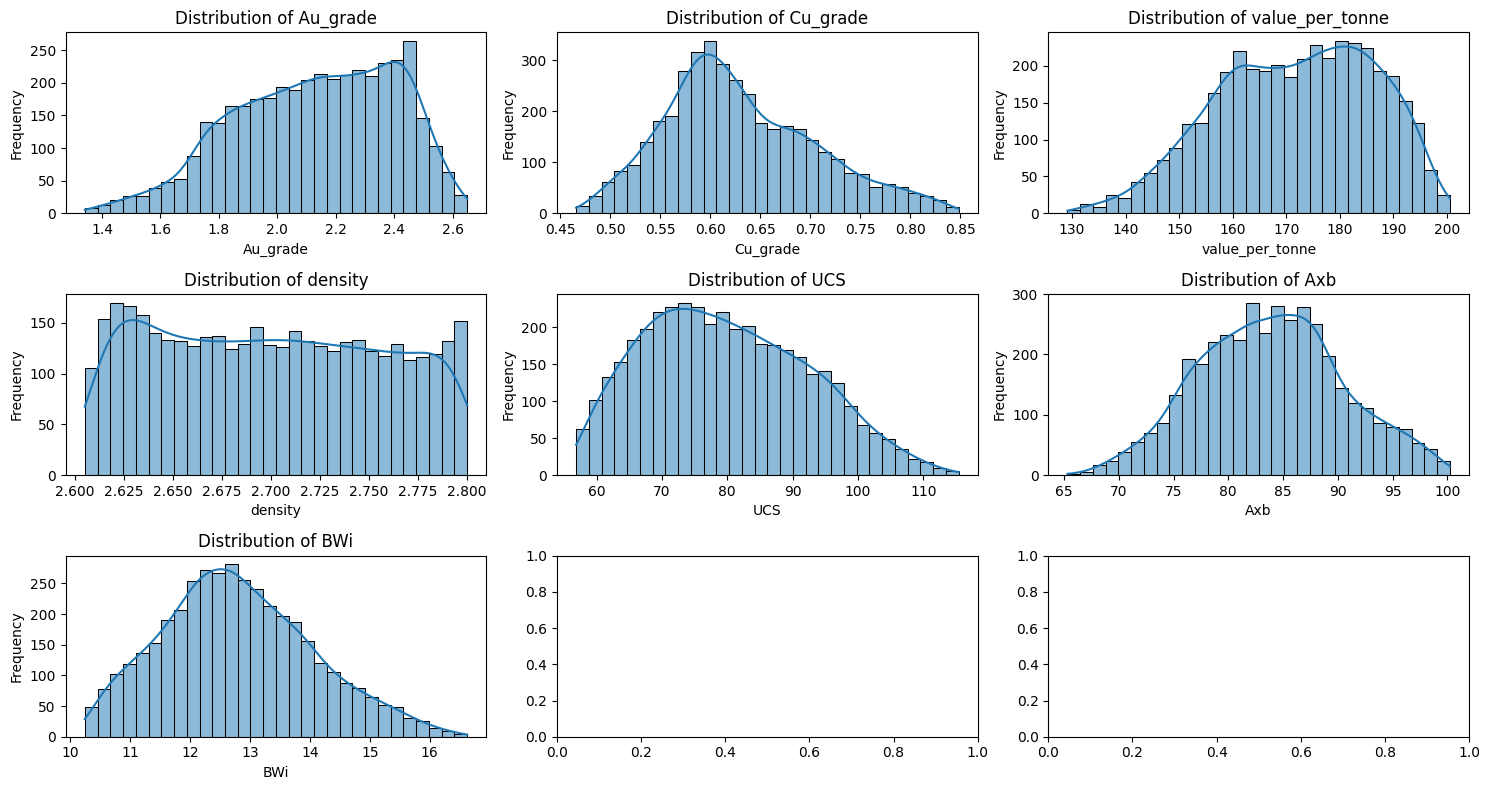

In [247]:
import seaborn as sns
import matplotlib.pyplot as plt
	
# Plot distibutions as a set of subplots
fig, axes = plt.subplots(3, 3, figsize=(15, 8))

for i, col in enumerate(['Au_grade', 'Cu_grade', 'value_per_tonne', 'density', 'UCS', 'Axb', 'BWi']):
	sns.histplot(block_model_df[col], kde=True, bins=30, ax=axes[i//3, i%3])
	axes[i//3, i%3].set_title(f"Distribution of {col}")
	axes[i//3, i%3].set_xlabel(col)
	axes[i//3, i%3].set_ylabel("Frequency")
	  
plt.tight_layout()
plt.show()


### 🛠️ 7.7: INTERACTIVE DRILLHOLE ASSAY VIEWER

Compare simulated drillhole assays for different metals.

- Choose a specific drillhole by ID
- Select **two metals** to plot against depth
- Automatically updates to avoid duplicate selections
- Grade plotted on X-axis, Depth on Y-axis (inverted for drillhole perspective)

Useful for:
- Visualising vertical grade distribution
- Comparing relative enrichment (e.g. Au vs Cu)

---

In [248]:
import numpy as np
import pandas as pd

# --- Generate Drillholes ---
n_holes = drillhole_parameters["n_holes"]
sampled_holes = []

x_values = sorted(block_model_df["x"].unique())
y_values = sorted(block_model_df["y"].unique())

np.random.seed(drillhole_parameters["random_seed"])
hole_coords = np.random.choice(len(x_values) * len(y_values), n_holes, replace=False)

for idx in hole_coords:
	xi = x_values[idx % len(x_values)]
	yi = y_values[idx // len(x_values)]

	hole_df = block_model_df[(block_model_df["x"] == xi) & (block_model_df["y"] == yi)].sort_values("z")
	hole_df = hole_df.copy()
	hole_df["hole_id"] = f"H{idx}"
	sampled_holes.append(hole_df)

drillhole_df = pd.concat(sampled_holes, ignore_index=True)

# --- Optional: View the generated holes ---
print(drillhole_df["hole_id"].unique())

import plotly.graph_objects as go
import ipywidgets as widgets
from IPython.display import display, clear_output

# --- Dropdown options based on mineral keys ---
available_metals = list(minerals.keys())
available_holes = drillhole_df['hole_id'].unique().tolist()

hole_dropdown = widgets.Dropdown(
	options=available_holes,
	value=available_holes[0],
	description='Drillhole:',
	layout=widgets.Layout(width='50%')
)

metal1_dropdown = widgets.Dropdown(
	options=available_metals,
	value=available_metals[0],
	description='Metal 1:',
	layout=widgets.Layout(width='50%')
)

metal2_dropdown = widgets.Dropdown(
	options=[m for m in available_metals if m != metal1_dropdown.value],
	value=[m for m in available_metals if m != metal1_dropdown.value][0],
	description='Metal 2:',
	layout=widgets.Layout(width='50%')
)

# --- Update metal2 when metal1 changes ---
def update_metal2_options(*args):
	metal2_dropdown.options = [m for m in available_metals if m != metal1_dropdown.value]
	if metal2_dropdown.value == metal1_dropdown.value:
		metal2_dropdown.value = metal2_dropdown.options[0]

metal1_dropdown.observe(update_metal2_options, names='value')

# --- Plot function ---
def plot_dual_metal_drillhole(hole_id, metal1, metal2):
	df = drillhole_df[drillhole_df['hole_id'] == hole_id]
	if df.empty:
		print(f"No data for hole: {hole_id}")
		return

	fig = go.Figure()
	for metal in [metal1, metal2]:
		grade_col = f"{metal}_grade"
		if grade_col in df.columns:
			fig.add_trace(go.Scatter(
				x=df[grade_col], y=df['z'],
				mode='lines+markers',
				name=f"{metal} Grade (g/t)",
				line=dict(shape='hv')
			))

	fig.update_yaxes(autorange='reversed', title='Depth (m)')
	fig.update_xaxes(title='Grade')
	fig.update_layout(title=f"Simulated Drillhole Assay – {hole_id}", height=500)
	fig.show()

# --- Link widgets to plot ---
widgets.interact(
	plot_dual_metal_drillhole,
	hole_id=hole_dropdown,
	metal1=metal1_dropdown,
	metal2=metal2_dropdown
)



['H332' 'H111' 'H352' 'H205' 'H56' 'H379' 'H81' 'H214' 'H142' 'H110']


interactive(children=(Dropdown(description='Drillhole:', layout=Layout(width='50%'), options=('H332', 'H111', …

<function __main__.plot_dual_metal_drillhole(hole_id, metal1, metal2)>

In [249]:
block_model_df.head()

,x,y,z,Au_grade,Cu_grade,density,mag_sus,resistivity,gamma,UCS,...,value_Au_per_tonne,value_Cu_per_tonne,value_per_tonne,class,domain,volume_m3,tonnes,block_id,value_smu,class_smu
0,12.5,12.5,5.0,1.750000,0.600000,2.700000,0.050500,550.0,100.000000,110.000000,...,100.937194,46.561668,147.498861,Waste,Background,6250,16875.000000,12.5_12.5_5.0,152.963635,Ore
1,37.5,12.5,5.0,1.871877,0.596801,2.700075,0.049028,550.0,102.641418,107.323220,...,107.966885,46.313452,154.280337,Ore,Background,6250,16875.469230,37.5_12.5_5.0,155.758900,Ore
2,62.5,12.5,5.0,2.011595,0.582894,2.700556,0.047628,550.0,105.142343,104.777324,...,116.025555,45.234224,161.259779,Ore,Background,6250,16878.472593,62.5_12.5_5.0,161.191710,Ore
3,87.5,12.5,5.0,2.159785,0.562914,2.701731,0.046359,550.0,107.391352,102.470715,...,124.572938,43.683724,168.256662,Ore,Background,6250,16885.819808,87.5_12.5_5.0,167.613441,Ore
4,112.5,12.5,5.0,2.294245,0.545528,2.703780,0.045269,550.0,109.306357,100.488701,...,132.328392,42.334519,174.662911,Ore,Background,6250,16898.626182,112.5_12.5_5.0,173.221170,Ore


### 💾 STEP 8: EXPORT FINAL BLOCK MODEL

Export the final block model with **all enhancements included**:

- Per-block economic values
- Ore/Waste classification
- Geological domains
- Summary stats
- Simulated drillholes (if desired)

The model is saved in **multiple formats** for flexibility:
- `.csv` (for general use or spreadsheet import)
- `.parquet` (efficient for large-scale data workflows)
- `.json` (ideal for APIs or web tools)


In [250]:
import os

# Export path setup
export_path = "../data/"
filename_base = "synthetic_block_model"
os.makedirs(export_path, exist_ok=True)

# File paths
csv_path = os.path.join(export_path, f"{filename_base}.csv")
parquet_path = os.path.join(export_path, f"{filename_base}.parquet")
json_path = os.path.join(export_path, f"{filename_base}.json")

# --- Export formats ---
block_model_df.to_csv(csv_path, index=False)
block_model_df.to_parquet(parquet_path, index=False)
block_model_df.to_json(json_path, orient="records", lines=True)

# Confirmation
print("✅ Block model exported successfully:")
print(f"  • CSV:     {csv_path}")
print(f"  • Parquet: {parquet_path}")
print(f"  • JSON:    {json_path}")

✅ Block model exported successfully:
  • CSV:     ../data/synthetic_block_model.csv
  • Parquet: ../data/synthetic_block_model.parquet
  • JSON:    ../data/synthetic_block_model.json


In [251]:
# Optional: Export drillhole assays
drillhole_path = os.path.join(export_path, f"{filename_base}_drillholes.csv")
drillhole_df.to_csv(drillhole_path, index=False)
print(f"  • Drillholes: {drillhole_path}")

  • Drillholes: ../data/synthetic_block_model_drillholes.csv


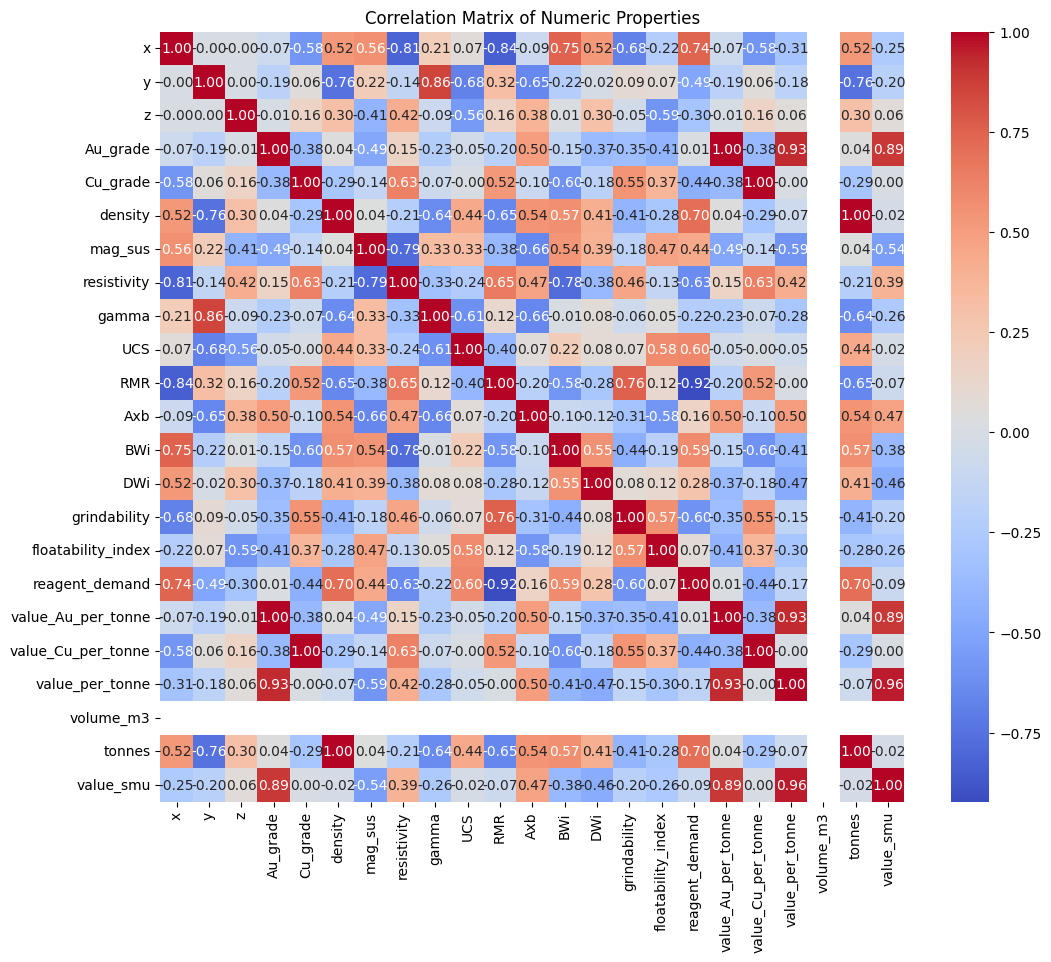

In [252]:
import seaborn as sns
import matplotlib.pyplot as plt

# Filter numeric columns
numeric_df = block_model_df.select_dtypes(include=['float64', 'int64'])

plt.figure(figsize=(12, 10))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix of Numeric Properties")
plt.show()
